In [1]:
!pip install scikit-learn catboost shap

In [2]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
)
from sklearn.metrics import roc_auc_score
from scipy.stats import randint, uniform

import sklearn

from catboost import CatBoostClassifier
import shap

import joblib
RANDOM_STATE = 111

In [3]:
TARGET = "SeriousDlqin2yrs"

DELAY_COLS = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]

# Признаки, которые НЕ логарифмируем:
LOG_EXCLUDE_COLS = [
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents",
    "TotalLatePayments",
    "WeightedDelinquency",
    "MaxDelinquencySeverity",
]

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

## Загрузка данных

In [4]:
DATA_DIR = Path("data")

df_raw = pd.read_csv(DATA_DIR / "cs-training.csv", index_col=0)
print(f"Shape: {df_raw.shape}")
print(f"Target rate: {df_raw[TARGET].mean():.4f}")
df_raw

Shape: (150000, 11)
Target rate: 0.0668


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [5]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

### Baseline Model

In [6]:
from sklearn.model_selection import cross_val_score

df_baseline = df_raw.copy()

X = df_baseline.drop(columns=[TARGET])
y = df_baseline[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

baseline_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )),
])

#Cross-validation 
cv_auc = cross_val_score(
    baseline_pipe,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)

print(
    f"Mean CV AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}"
)


baseline_pipe.fit(X_train, y_train)

#Test ROC-AUC

y_pred_proba = baseline_pipe.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Test ROC-AUC: {test_auc:.4f}")

baseline_cv_auc = cv_auc.mean()
baseline_test_auc = test_auc

Mean CV AUC: 0.7877 ± 0.0054
Test ROC-AUC: 0.7864


ROC-AUC: 0.7864
PR-AUC: 0.3107


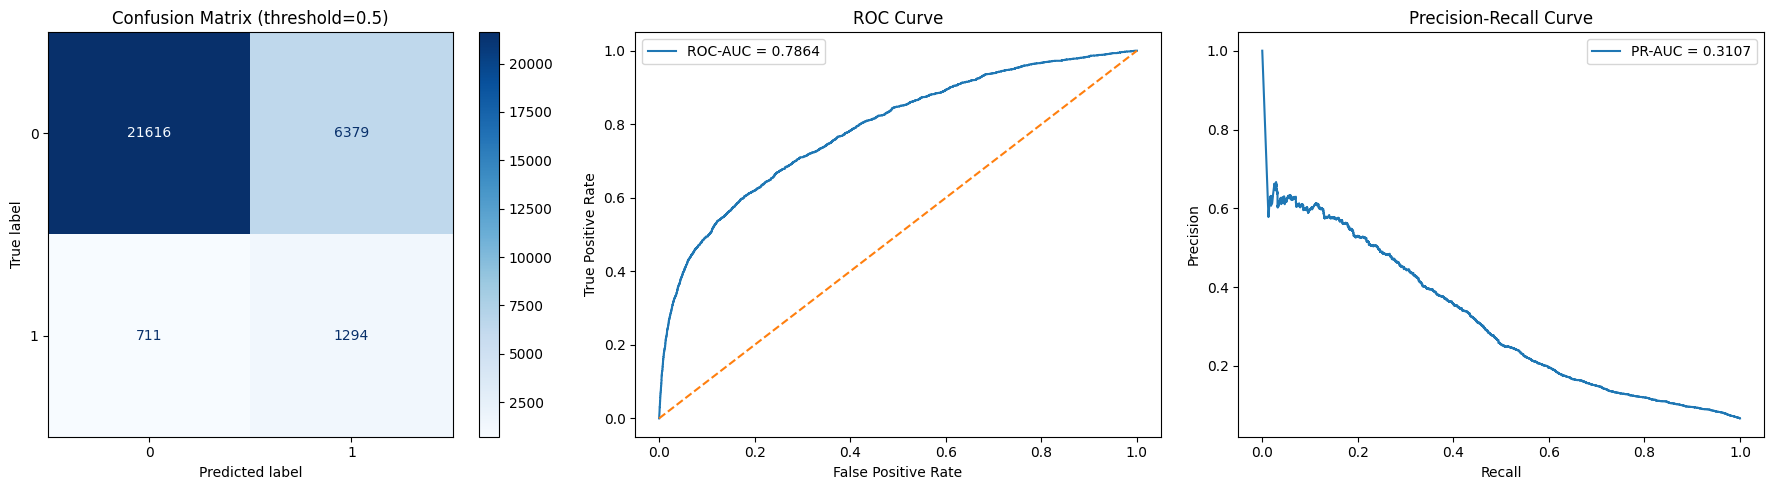

In [7]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
)


# ── predictions ─────────────────────────────────────────────
y_proba = baseline_pipe.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

# ── ROC-AUC, PR-AUC ───────────────────────────────────────────
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.4f}")
pr_auc = average_precision_score(y_test, y_proba)
print(f"PR-AUC: {pr_auc:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[0], cmap=plt.cm.Blues, values_format="d")
axes[0].set_title("Confusion Matrix (threshold=0.5)")

# ── ROC curve ────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

# ── PR curve ─────────────────────────────────────────────────
precision, recall, _ = precision_recall_curve(y_test, y_proba)
axes[2].plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].legend()

plt.tight_layout()
plt.show()

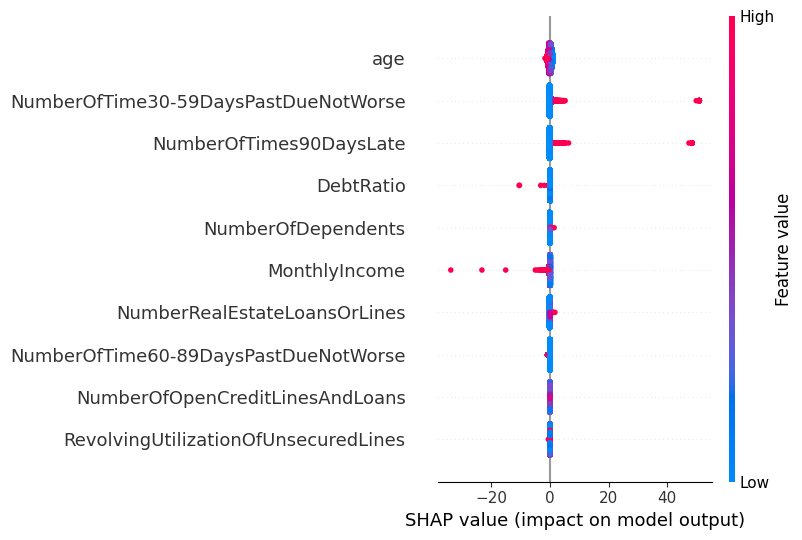

In [8]:
feature_names = baseline_pipe[:-1].get_feature_names_out()

X_train_transformed = baseline_pipe[:-1].transform(X_train)
X_test_transformed = baseline_pipe[:-1].transform(X_test)

model = baseline_pipe.named_steps["model"]

explainer = shap.LinearExplainer(model, X_train_transformed)
shap_values = explainer(X_test_transformed)

# summary plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

## Base Preprocessing

In [9]:
def base_clean(df: pd.DataFrame) -> pd.DataFrame:
    """
    Чистка сырых данных.

    - Удаляем age < 21 (ошибки данных)
    - Клиппим age до 95
    - MonthlyIncome == 0 -> NaN (нулевой доход -- отсутствие данных)
    - Значения 96/98 в delay_cols -> NaN (технические коды)
    - RevUtil > 2.0 -> NaN (ошибки в данных)
    """
    df = df.loc[df["age"] >= 21].copy()
    df["age"] = df["age"].clip(upper=95)

    df.loc[df["MonthlyIncome"] == 0, "MonthlyIncome"] = np.nan

    df[DELAY_COLS] = df[DELAY_COLS].replace([96, 98], np.nan)

    df.loc[
        df["RevolvingUtilizationOfUnsecuredLines"] > 2.0,
        "RevolvingUtilizationOfUnsecuredLines",
    ] = np.nan

    return df

## 2. Feature Engineering

### 2.1 Бинарные флаги

- income_missing: MonthlyIncome == 0 или NaN 
- dependents_missing: NumberOfDependents is NaN
- has_dependents: NumberOfDependents > 0
- is_young: age < 25
- revutil_over_limit: RevolvingUtilizationOfUnsecuredLines > 1.0
- no_open_lines: NumberOfOpenCreditLinesAndLoans == 0
- has_real_estate_loan: NumberRealEstateLoansOrLines > 0
- ever_late_30_59: N30-59 > 0
- ever_late_60_89: N60-89 > 0
- ever_90_days_late: N90+ > 0
- HasAnyDelinquency: Total Late Payments > 0

### 2.2 Новые числовые признаки

Заполним пропуски в NumberOfDependents на медиану (0) и обрежем NumberOfTime... до максимального значения 10.

- TotalLatePayments: sum of all types of deliquencies
- WeightedDelinquency: 1\*N30-59 + 2\*N60-89 + 3\*N90+
- MaxDelinquencySeverity (0-3): max severity of deliquencies
- monthly_debt_payment: DebtRatio * MonthlyIncome (MonthlyIncome is not NaN, otherwise monthly_debt_payment=NaN)
- income_per_dependent: MonthlyIncome / (Dependents + 1) (=NaN if Income=NaN)
- total_credit_lines: OpenLines + RealEstateLines

In [10]:
def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    """
    Добавляет бинарные флаги и числовые производные признаки.
    Не использует статистику данных.
    """
    df = df.copy()
    n30 = df["NumberOfTime30-59DaysPastDueNotWorse"]
    n60 = df["NumberOfTime60-89DaysPastDueNotWorse"]
    n90 = df["NumberOfTimes90DaysLate"]

    # ── Бинарные флаги ────────────────────────────────────────────────────
    df["income_missing"]       = (df["MonthlyIncome"].isna()).astype(int)
    df["dependents_missing"]   = df["NumberOfDependents"].isna().astype(int)
    df["has_dependents"]       = (df["NumberOfDependents"].fillna(0) > 0).astype(int)
    df["is_young"]             = (df["age"] < 25).astype(int)
    df["is_old"]               = (df["age"] > 63).astype(int)
    df["revutil_over_limit"]   = np.where(
        df["RevolvingUtilizationOfUnsecuredLines"].isna(), np.nan,
        (df["RevolvingUtilizationOfUnsecuredLines"] > 1.0).astype(float),
    )
    df["no_open_lines"]        = (df["NumberOfOpenCreditLinesAndLoans"] == 0).astype(int)
    df["has_real_estate_loan"] = (df["NumberRealEstateLoansOrLines"] > 0).astype(int)
    df["ever_late_30_59"]      = (n30.fillna(0) > 0).astype(int)
    df["ever_late_60_89"]      = (n60.fillna(0) > 0).astype(int)
    df["ever_90_days_late"]    = (n90.fillna(0) > 0).astype(int)

    # ── Числовые агрегаты просрочек ───────────────────────────────────────
    df["TotalLatePayments"]      = df[DELAY_COLS].fillna(0).sum(axis=1)
    df["WeightedDelinquency"]    = n30.fillna(0) + 2 * n60.fillna(0) + 3 * n90.fillna(0)
    df["MaxDelinquencySeverity"] = np.maximum.reduce([
        (n30.fillna(0) > 0) * 1,
        (n60.fillna(0) > 0) * 2,
        (n90.fillna(0) > 0) * 3,
    ])

    # ── Финансовые производные ────────────────────────────────────────────
    df["monthly_debt_payment"] = df["DebtRatio"] * df["MonthlyIncome"]
    df["income_per_dependent"] = df["MonthlyIncome"] / (df["NumberOfDependents"].fillna(0) + 1)
    df["total_credit_lines"]   = (
        df["NumberOfOpenCreditLinesAndLoans"] + df["NumberRealEstateLoansOrLines"]
    )

    # Клиппинг счётчиков просрочек: > 10 — ошибки данных, не выбросы
    df[DELAY_COLS] = df[DELAY_COLS].clip(upper=10)

    return df

In [11]:
df_base = base_clean(df_raw)

X = df_base.drop(columns=[TARGET])
y = df_base[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train : {X_train.shape}  | default rate: {y_train.mean():.4f}")
print(f"Test  : {X_test.shape}   | default rate: {y_test.mean():.4f}")
print(f"Features: {X_train.columns.tolist()}")

Train : (119999, 10)  | default rate: 0.0668
Test  : (30000, 10)   | default rate: 0.0668
Features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


# 3. Model-Specific Preprocessing 

Четыре кастомных класса + стандартный `SimpleImputer`.

Обучение трансформеров на X_train.

In [12]:
class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        self.feature_names_out_ = feature_engineering(df).columns.tolist()
        return self

    def transform(self, X):
        return feature_engineering(X)

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_out_)

In [13]:
class ColumnClipper(BaseEstimator, TransformerMixin):
    """
    Клиппит числовые признаки (не бинарные) по верхнему квантилю.

    Parameters
    ----------
    quantile : float, default=0.99
    binary_threshold : int, default=2
        Столбцы с <= binary_threshold уникальных значений пропускаются.
    """

    def __init__(self, quantile: float = 0.99, binary_threshold: int = 2):
        self.quantile = quantile
        self.binary_threshold = binary_threshold

    def fit(self, X, y=None):
        df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        self.num_cols_ = [
            c for c in df.select_dtypes(include=np.number).columns
            if df[c].nunique() > self.binary_threshold
        ]
        self.clip_upper_ = {col: df[col].quantile(self.quantile) for col in self.num_cols_}
        self.feature_names_in_ = df.columns.tolist()
        return self

    def transform(self, X):
        df = (
            pd.DataFrame(X, columns=self.feature_names_in_)
            if not isinstance(X, pd.DataFrame) else X.copy()
        )
        for col, upper in self.clip_upper_.items():
            df[col] = df[col].clip(upper=upper)
        return df
        
    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_)

In [14]:
class Log1pTransformer(BaseEstimator, TransformerMixin):
    """
    np.log1p к числовым признакам, кроме бинарных и exclude_cols.

    Parameters
    ----------
    exclude_cols : list[str], optional
        Признаки, которые НЕ логарифмируются. По умолчанию LOG_EXCLUDE_COLS.
    binary_threshold : int, default=2
        Столбцы с <= binary_threshold уникальных значений пропускаются.
    """

    def __init__(self, exclude_cols=None, binary_threshold: int = 2):
        self.exclude_cols = exclude_cols
        self.binary_threshold = binary_threshold

    def fit(self, X, y=None):
        df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        exclude = self.exclude_cols if self.exclude_cols is not None else LOG_EXCLUDE_COLS
        self.log_cols_ = [
            c for c in df.select_dtypes(include=np.number).columns
            if c not in exclude and df[c].nunique() > self.binary_threshold
        ]
        self.feature_names_in_ = df.columns.tolist()
        return self

    def transform(self, X):
        df = (
            pd.DataFrame(X, columns=self.feature_names_in_)
            if not isinstance(X, pd.DataFrame) else X.copy()
        )
        for col in self.log_cols_:
            df[col] = np.log1p(df[col].clip(lower=0))
        return df

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_)

In [15]:
class SelectiveScaler(BaseEstimator, TransformerMixin):
    """
    StandardScaler только для числовых не-бинарных признаков.
    
    Parameters
    ----------
    binary_threshold : int, default=2
        Столбцы с <= binary_threshold уникальных значений пропускаются.
    """

    def __init__(self, binary_threshold: int = 2):
        self.binary_threshold = binary_threshold

    def fit(self, X, y=None):
        df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        self.num_cols_ = [
            c for c in df.select_dtypes(include=np.number).columns
            if df[c].nunique() > self.binary_threshold
        ]
        self.scaler_ = StandardScaler().fit(df[self.num_cols_])
        self.feature_names_in_ = df.columns.tolist()
        return self

    def transform(self, X):
        df = (
            pd.DataFrame(X, columns=self.feature_names_in_)
            if not isinstance(X, pd.DataFrame) else X.copy()
        )
        df[self.num_cols_] = self.scaler_.transform(df[self.num_cols_])
        return df

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_)

## Сборка препроцессора

Одна функция с флагами - каждая модель берёт нужную комбинацию шагов.  
Порядок шагов:  
new features  
-> imputer  
-> clipper  
-> log  
-> scaler

In [16]:
def build_preprocessor(
    fe: bool = True,
    clip: bool = True,
    log:  bool = True,
    scale: bool = True,
) -> Pipeline:
    """
    Собирает пайплайн препроцессинга из флагов.

    Parameters
    ----------
    fe    : включить использование сгенерированных признаков
    clip  : включить клиппинг выбросов по p99 тренировочных данных
    log   : включить log1p для skewed признаков
    scale : включить скейлер
    """
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if fe:
        steps.insert(0, ("fe", FeatureEngineeringTransformer()))
    if clip:
        steps.append(("clipper", ColumnClipper(quantile=0.99)))
    if log:
        steps.append(("log", Log1pTransformer()))
    if scale:
        steps.append(("scaler", SelectiveScaler()))

    pipeline = Pipeline(steps)
    pipeline.set_output(transform="pandas")
    return pipeline

## Конфиги моделей
Каждый словарь задаёт:
- `preprocessor` — флаги сборки (fe/clip/log/scale)
- `model` — экземпляр модели
- `param_grid` — сетка гиперпараметров (с префиксом `model__`)
- `search` — тип поиска (`grid` или `random`)


In [17]:
MODELS = {

    # ── Logistic Regression ─────────────────────────────────────────────────
    # Линейная модель, включаем scale (чувствительна к масштабу)
    # и log (нормализует распределения, улучшая сходимость).
    "logreg": {
        "preprocessor": build_preprocessor(fe=True, clip=True, log=True, scale=True),
        "model": LogisticRegression(
            class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
        ),
        "param_grid": {
            "model__C":       [0.001, 0.01, 0.1, 1.0, 10.0],
            "model__penalty": ["l1", "l2"],
            "model__solver":  ["liblinear"],
        },
        "search": "grid",
    },

    # ── kNN ─────────────────────────────────────────────────────────────────
    # Метрическая модель, критически зависит от scale.
    # clip + log убирают выбросы, которые иначе доминировали бы в метрике.
    "knn": {
        "preprocessor": build_preprocessor(fe=True, clip=True, log=True, scale=True),
        "model": KNeighborsClassifier(),
        "param_grid": {
            "model__n_neighbors": [11, 21, 51, 101],
            "model__weights":     ["uniform", "distance"],
            "model__metric":      ["euclidean", "manhattan"],
        },
        "search": "grid",
    },

    # ── Random Forest ────────────────────────────────────────────────────────
    # scale и log не нужны.
    # clip=True оставляем: умеренный p99 убирает явные ошибки в данных, не мешая дереву самому находить сплиты.
    "random_forest": {
        "preprocessor": build_preprocessor(fe=True, clip=True, log=False, scale=False),
        "model": RandomForestClassifier(
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
        ),
        "param_grid": {
            "model__n_estimators":     randint(100, 500),
            "model__max_depth":        randint(4, 15),
            "model__min_samples_leaf": randint(10, 50),
            "model__max_features":     ["sqrt", "log2"],
        },
        "search": "random",
        "n_iter": 20,
    },

    # ── CatBoost ─────────────────────────────────────────────────────────────
    # Препроцессинг минимальный
    "catboost": {
        "preprocessor": build_preprocessor(fe=True, clip=False, log=False, scale=False),
        "model": CatBoostClassifier(
            auto_class_weights="Balanced",
            random_seed=RANDOM_STATE,
            verbose=False,
        ),
        "param_grid": {
            "model__depth":         randint(4, 10),
            "model__learning_rate": uniform(0.01, 0.2),
            "model__iterations":    randint(200, 600),
            "model__l2_leaf_reg":   randint(1, 10),
        },
        "search": "random",
        "n_iter": 30,
    },
}

## 4. Обучение и подбор гиперпараметров

In [18]:
FORCE_RETRAIN = False

results = {}

for name, cfg in MODELS.items():
    model_path = MODELS_DIR / f"{name}.joblib"

    # Загрузка сохранённой модели
    if model_path.exists() and not FORCE_RETRAIN:
        print(f"\n  {name.upper()} — загружаем из {model_path}")
        results[name] = joblib.load(model_path)
        print(f"  CV AUC   : {results[name]['cv_auc']:.4f}")
        print(f"  Test AUC : {results[name]['test_auc']:.4f}")
        continue

    # ─ Обучение ──────────────────────────────────────────────────────────
    print(f"\n{'─' * 55}")
    print(f"  {name.upper()} — обучаем")
    print(f"{'─' * 55}")

    pipeline = Pipeline([
        ("preprocessor", cfg["preprocessor"]),
        ("model",        cfg["model"]),
    ])

    if cfg["search"] == "grid":
        search = GridSearchCV(
            estimator=pipeline,
            param_grid=cfg["param_grid"],
            cv=CV,
            scoring="roc_auc",
            n_jobs=-1,
            refit=True,
            return_train_score=True,
        )
    else:
        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=cfg["param_grid"],
            n_iter=cfg.get("n_iter", 20),
            cv=CV,
            scoring="roc_auc",
            n_jobs=-1,
            refit=True,
            return_train_score=True,
            random_state=RANDOM_STATE,
        )

    search.fit(X_train, y_train)

    y_proba  = search.best_estimator_.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_proba)

    result = {
        "best_estimator": search.best_estimator_,
        "best_params":    search.best_params_,
        "cv_auc":         search.best_score_,
        "test_auc":       test_auc,
        "y_proba":        y_proba,
    }

    # ── Сохранение ─────────────────────────────────────────────────────────
    joblib.dump(result, model_path)
    results[name] = result

    print(f"  Best params : {result['best_params']}")
    print(f"  CV AUC      : {result['cv_auc']:.4f}")
    print(f"  Test AUC    : {result['test_auc']:.4f}")
    print(f"  Сохранено   : {model_path}")


  LOGREG — загружаем из models\logreg.joblib
  CV AUC   : 0.8600
  Test AUC : 0.8585

  KNN — загружаем из models\knn.joblib
  CV AUC   : 0.8517
  Test AUC : 0.8491

  RANDOM_FOREST — загружаем из models\random_forest.joblib
  CV AUC   : 0.8651
  Test AUC : 0.8628

  CATBOOST — загружаем из models\catboost.joblib
  CV AUC   : 0.8663
  Test AUC : 0.8647


## 5. Сравнение результатов

In [19]:
baseline_row = pd.DataFrame([{
    "model": "logreg_baseline",
    "cv_auc": baseline_cv_auc,
    "test_auc": baseline_test_auc,
    "delta": baseline_test_auc - baseline_cv_auc,
}])

results_df = (
    pd.DataFrame([
        {
            "model":    name,
            "cv_auc":   v["cv_auc"],
            "test_auc": v["test_auc"],
            "delta":    v["test_auc"] - v["cv_auc"],   # > 0 → тест лучше CV (редко), < 0 → небольшой оверфит
        }
        for name, v in results.items()
    ])
    .sort_values("test_auc", ascending=False)
    .reset_index(drop=True)
)

results_df = (
    pd.concat([results_df, baseline_row], ignore_index=True)
    .sort_values("test_auc", ascending=False)
    .reset_index(drop=True)
)

display(
    results_df.style
    .format({"cv_auc": "{:.4f}", "test_auc": "{:.4f}", "delta": "{:+.4f}"})
    .background_gradient(subset=["test_auc"], cmap="RdYlGn")
)

best_model_name = results_df.iloc[0]["model"]
print(f"\nЛучшая модель: {best_model_name} (Test AUC = {results_df.iloc[0]['test_auc']:.4f})")

,model,cv_auc,test_auc,delta
0,catboost,0.8663,0.8647,-0.0016
1,random_forest,0.8651,0.8628,-0.0022
2,logreg,0.8600,0.8585,-0.0014
3,knn,0.8517,0.8491,-0.0026
4,logreg_baseline,0.7877,0.7864,-0.0013



Лучшая модель: catboost (Test AUC = 0.8647)


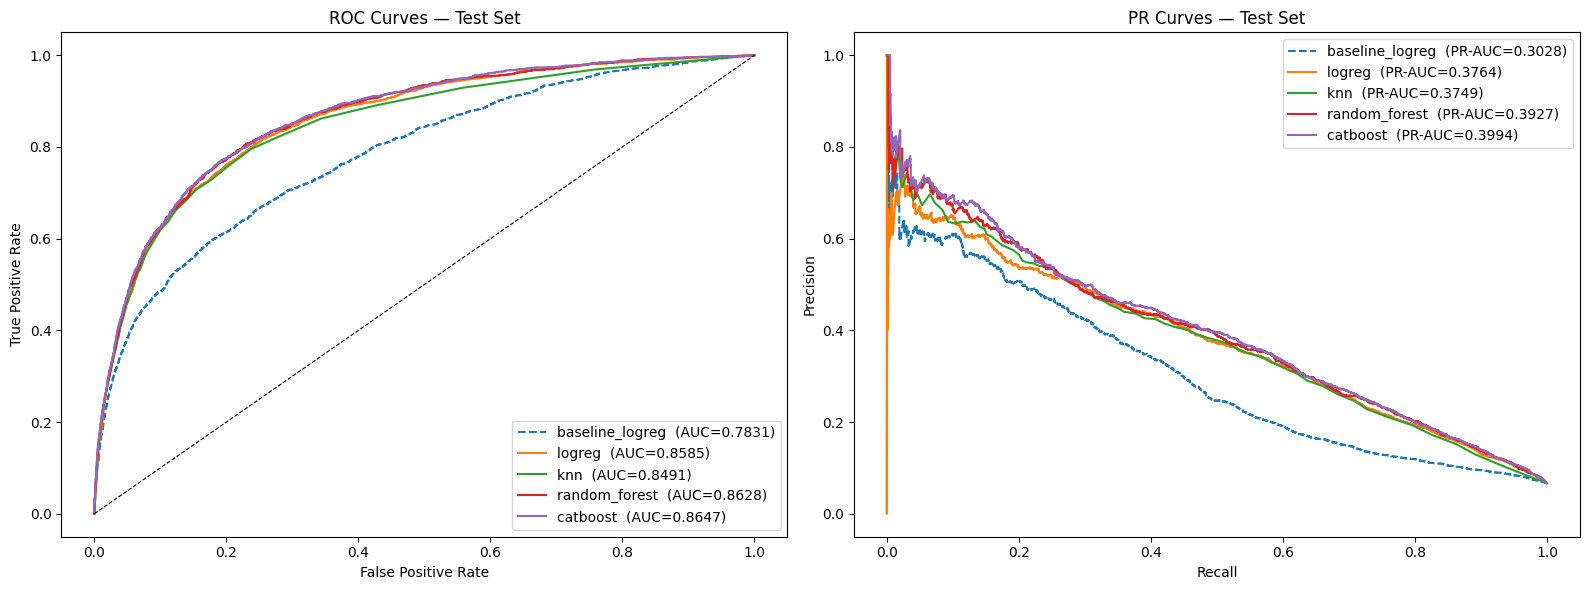

In [20]:
# ROC-кривые и PR-кривые всех моделей (включая baseline_logreg)
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
)

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(16, 6))

# ── baseline_logreg ───────────────────────────────────────────────────────
bl_proba  = baseline_pipe.predict_proba(X_test)[:, 1]
bl_roc    = roc_auc_score(y_test, bl_proba)
bl_pr     = average_precision_score(y_test, bl_proba)

bl_fpr, bl_tpr, _ = roc_curve(y_test, bl_proba)
ax_roc.plot(bl_fpr, bl_tpr, linestyle="--",
            label=f"baseline_logreg  (AUC={bl_roc:.4f})")

bl_prec, bl_rec, _ = precision_recall_curve(y_test, bl_proba)
ax_pr.plot(bl_rec, bl_prec, linestyle="--",
           label=f"baseline_logreg  (PR-AUC={bl_pr:.4f})")

# ── Other models ───────────────────────────────────────────────────────────
for name, v in results.items():
    fpr, tpr, _ = roc_curve(y_test, v["y_proba"])
    ax_roc.plot(fpr, tpr, label=f"{name}  (AUC={v['test_auc']:.4f})")

    pr_auc = average_precision_score(y_test, v["y_proba"])
    prec, rec, _ = precision_recall_curve(y_test, v["y_proba"])
    ax_pr.plot(rec, prec, label=f"{name}  (PR-AUC={pr_auc:.4f})")

# ── ROC axes ──────────────────────────────────────────────────────────────
ax_roc.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curves — Test Set")
ax_roc.legend(loc="lower right")

# ── PR axes ───────────────────────────────────────────────────────────────
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("PR Curves — Test Set")
ax_pr.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [21]:
# ── Сводная таблица метрик ───────────────────────────────────
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

def compute_metrics(name: str, y_proba) -> dict:
    y_pred = (y_proba >= 0.5).astype(int)
    return {
        "Model":   name,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "F1":        f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_test, y_proba),
        "PR-AUC":    average_precision_score(y_test, y_proba),
    }

rows = []

# baseline
bl_proba = baseline_pipe.predict_proba(X_test)[:, 1]
rows.append(compute_metrics("baseline_logreg", bl_proba))

# other models
for name, v in results.items():
    rows.append(compute_metrics(name, v["y_proba"]))

summary_df = (
    pd.DataFrame(rows)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(
    summary_df.style
    .format({
        "Precision": "{:.4f}",
        "Recall":    "{:.4f}",
        "F1":        "{:.4f}",
        "ROC-AUC":   "{:.4f}",
        "PR-AUC":    "{:.4f}",
    })
    .background_gradient(subset=["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"],
                         cmap="RdYlGn")
    .set_caption("Summary Table — Test Set Metrics")
)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,catboost,0.2179,0.7746,0.3401,0.8647,0.3994
1,random_forest,0.2510,0.7202,0.3723,0.8628,0.3927
2,logreg,0.2243,0.7431,0.3446,0.8585,0.3764
3,knn,0.5930,0.1686,0.2625,0.8491,0.3749
4,baseline_logreg,0.1677,0.6404,0.2658,0.7831,0.3028


## 6. Интерпретация результатов SHAP
Explainer выбирается по типу модели:
- `TreeExplainer` — RandomForest, CatBoost
- `LinearExplainer` — LogisticRegression
- `KernelExplainer` — kNN (на подвыборке)

In [22]:
def normalize_shap_values(shap_values):
    if isinstance(shap_values, list):
        return shap_values[1]

    if isinstance(shap_values, np.ndarray):
        if shap_values.ndim == 3:
            return shap_values[:, :, 1]
        return shap_values

    return shap_values


def get_shap_values(estimator, X_processed: pd.DataFrame):
    """
    Возвращает shap_values (np.ndarray) и explainer для любого типа модели.
    Работает с Pipeline — извлекает модель из шага 'model'.
    """
    model = estimator.named_steps["model"]

    if isinstance(model, (RandomForestClassifier, CatBoostClassifier)):
        explainer   = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_processed)
        sv          = normalize_shap_values(shap_values)

    elif isinstance(model, LogisticRegression):
        explainer   = shap.LinearExplainer(model, X_processed)
        shap_values = explainer.shap_values(X_processed)
        sv          = normalize_shap_values(shap_values)

    else:
        # kNN
        background  = shap.sample(X_processed, min(100, len(X_processed)))
        explainer   = shap.KernelExplainer(model.predict_proba, background)
        shap_values = explainer.shap_values(X_processed, nsamples=100)
        sv          = normalize_shap_values(shap_values)

    return sv, explainer


──────────────────────────────────────────────────────────────────────
Оценка модели: logreg
──────────────────────────────────────────────────────────────────────


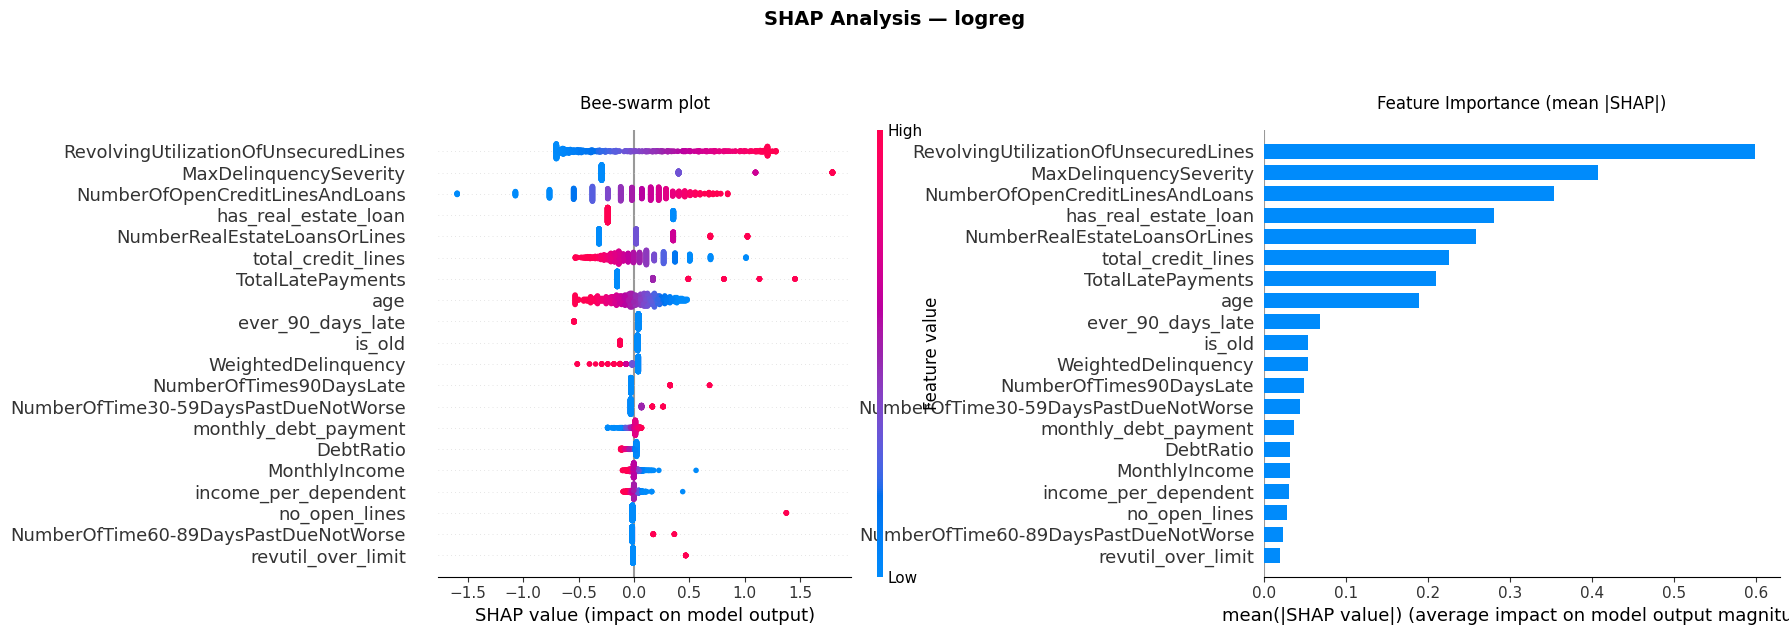


──────────────────────────────────────────────────────────────────────
Оценка модели: knn
──────────────────────────────────────────────────────────────────────


  0%|          | 0/200 [00:00<?, ?it/s]

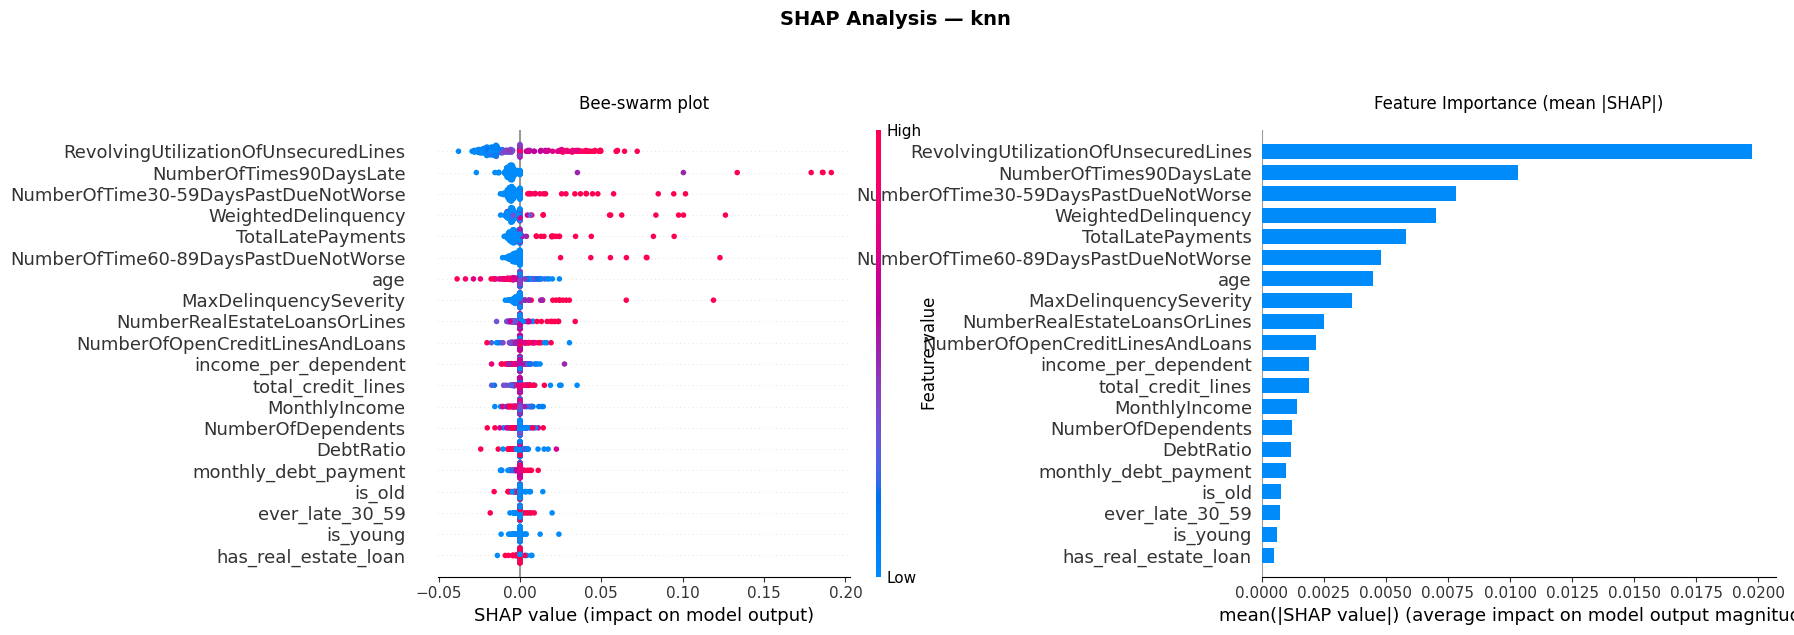


──────────────────────────────────────────────────────────────────────
Оценка модели: random_forest
──────────────────────────────────────────────────────────────────────


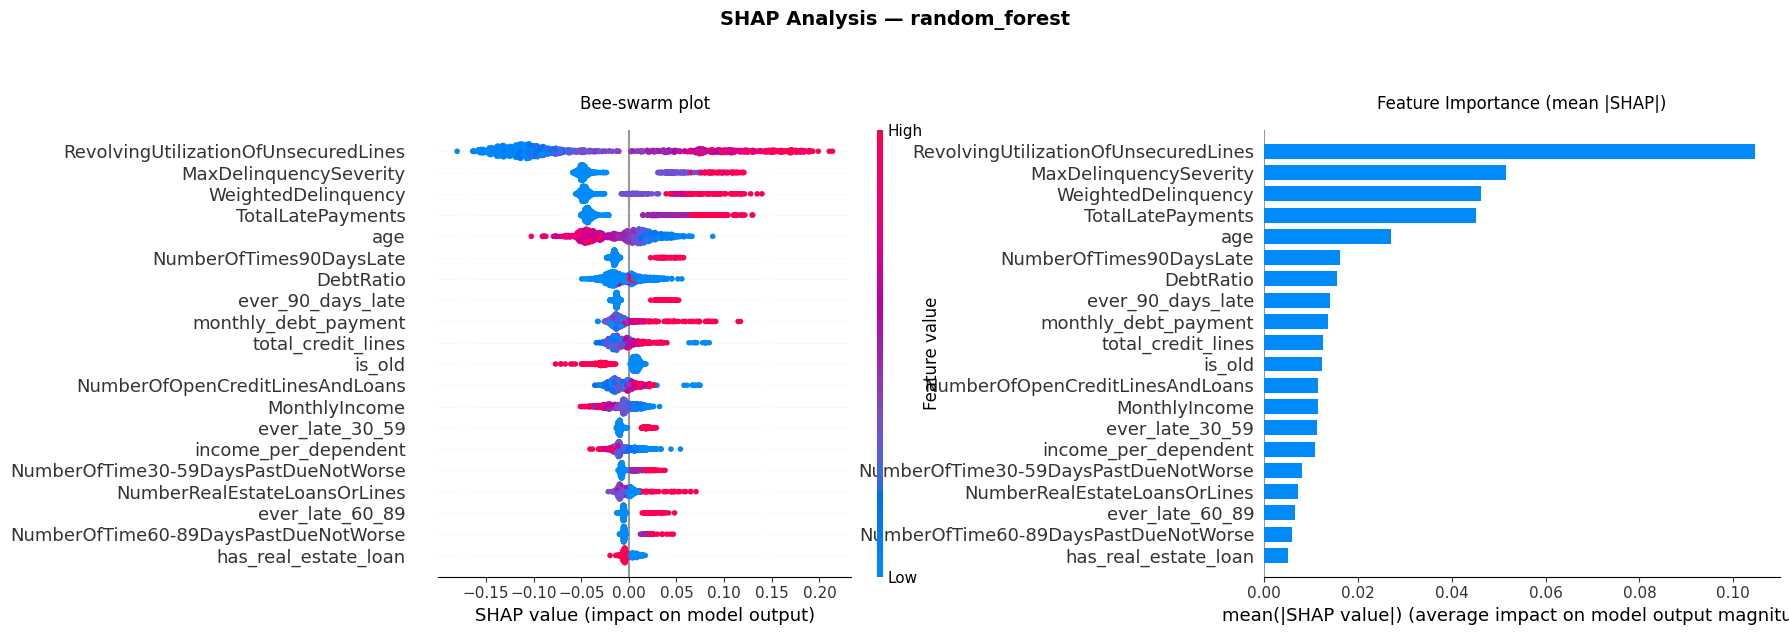


──────────────────────────────────────────────────────────────────────
Оценка модели: catboost
──────────────────────────────────────────────────────────────────────


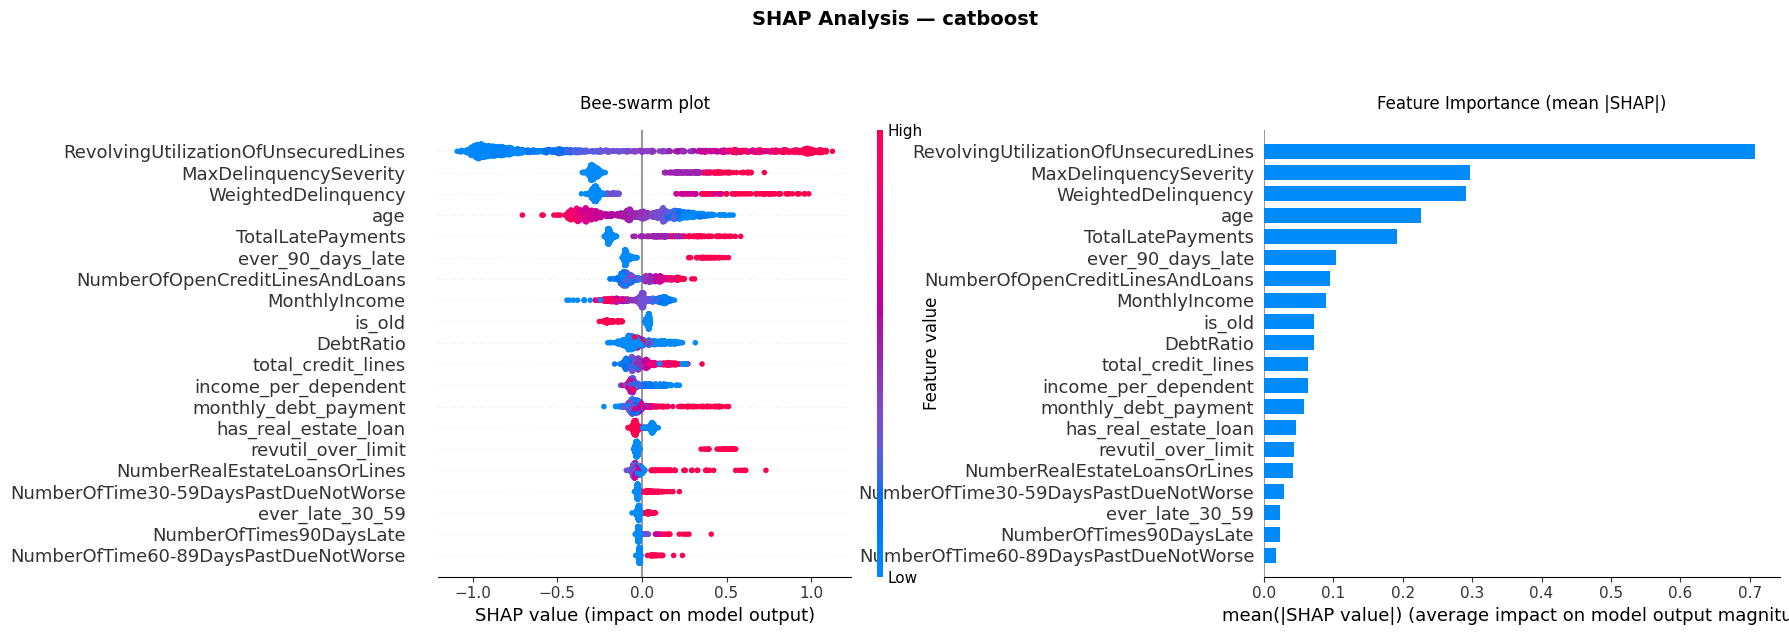

In [23]:
shap.initjs()
rng = np.random.default_rng(RANDOM_STATE)

# ── SHAP Summary + Bar plot ──────────────────────────────────
for name, v in results.items():
    print(f"\n{'─' * 70}")
    print(f"Оценка модели: {name}")
    print(f"{'─' * 70}")

    est  = v["best_estimator"]
    prep = est.named_steps["preprocessor"]
    X_proc = prep.transform(X_test)

    # Размер выборки
    if name == "knn":
        n_sample = min(200, len(X_proc))
    elif name in ["random_forest", "catboost"]:
        n_sample = min(1000, len(X_proc))
    else:
        n_sample = min(500, len(X_proc))

    idx_s = rng.choice(len(X_proc), size=n_sample, replace=False)
    X_s   = X_proc.iloc[idx_s].reset_index(drop=True)

    try:
        sv_s, _ = get_shap_values(est, X_s)

        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        
        fig.suptitle(f"SHAP Analysis — {name}", fontsize=14, fontweight='bold', y=1.05)

        # Bee-swarm
        plt.sca(axes[0])
        shap.summary_plot(sv_s, X_s, max_display=20, plot_size=None, show=False)
        axes[0].set_title("Bee-swarm plot", fontsize=12, pad=15)

        # Feature Importance (bar)
        plt.sca(axes[1])
        shap.summary_plot(sv_s, X_s, plot_type="bar", max_display=20, plot_size=None, show=False)
        axes[1].set_title("Feature Importance (mean |SHAP|)", fontsize=12, pad=15)

        plt.subplots_adjust(wspace=0.6, top=0.85)
        
        plt.show()

    except Exception as e:
        print(f"Ошибка для модели {name}: {e}")

# 7. Conclusions  
`Model Performance:`
- CatBoost, RF и LogReg сгруппированы в диапазоне по ROC-AUC 0.858–0.865 — разрыв несущественен. Бустинг не даёт принципиального выигрыша перед линейной моделью.
- RF показывает лучший F1 (0.37), CatBoost — лучший Recall (0.77) и PR-AUC (0.40).
- kNN показал себя плохо применимым для текущей задачи: kNN: Precision 0.59, Recall 0.17. Улавливает только очевидные дефолты, обучается заметно дольше других моделей.
- (Что можно сказать про precision, recall, f1, pr?)
- Градиентный бустинг не показывает сильного улучшения качества по ROC-AUC в сравнении с логистической регрессией. При этом линейная модель является дает более интерпретируемый результат. (Верный ли это вывод? А что насчет RF?)

`Важно:` Метрики Precision/Recall/F1 получены при threshold=0.5. Ошибки FN и FP имеют разную стоимость, поэтому требуется тюнинг порога через cost-функцию или минимизацию FN при фиксированном FP. В обоих случаях коэффициенты выбирает бизнес.

`Insights:`
- `RevolvingUtilizationOfUnsecuredLines` — главный предиктор дефолта во всех моделях (доля использования беззалоговых кредитных линий).
- Следующие по важности - признаки, связанные с предыдущими просрочками и возраст.
- Серьезность просрочек (WeightedDelinquency, MaxDelinquencySeverity) важнее, чем их количество.
- Сам по себе доход играет не самую значимую роль в разделении классов.

**Итог.**
При сопоставимом качестве LogReg — предпочтительный выбор, если в задаче требуется прозрачность и интерпретируемость.